### BNN regression, example 2 (Housing -dataset), Hyperparemeter experimentation 

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim

# pip install torchbnn
import torchbnn as bnn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, explained_variance_score
import seaborn as sns

In [48]:
# Load dataset
# So, we have 20K + rows but we need 3000-4000 rows to implement BNN regression.
df = pd.read_csv("Housing.csv")

df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [49]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [50]:
# As this dataset has lon and lat, I will drop them and create "distance_to_nearest_city" based on coordinates,
# Also, "ocean_proximity" is a categorical variable, so I will one-hot encode it. I did that many times already in previous courses,
# so, i will download modified dataset from Advanced Data Analysis course Project 1 and will use here:

df = pd.read_csv("housing_modified.csv")  
df.describe()  

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155,89.803481,0.442128,0.317917,0.000245,0.111095
std,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099,84.324286,0.496652,0.465678,0.015641,0.314257
min,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000,22.810000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000,57.990000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000,140.190000,1.000000,1.000000,0.000000,0.000000
max,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,489.120000,1.000000,1.000000,1.000000,1.000000


In [51]:
# Still we have 20K + rows, so I will trim the extreme values of the target 
# and also use quantile for other variables that have skewed distributional.
# I implemented that many times, I will paste here the path to the notebook in Git where i did that. 
# https://github.com/RovSveta/Advanced_Data_analytics_2025/blob/main/Exercise_project_1/Regression_dataset/outlier_and_noise_detection.ipynb
# I will use trimmed hoising dataset from that notebook, which is already preprocessed and ready to use for BNN regression.
df = pd.read_csv("housing_trimmed_variables.csv")  
df.describe()  

,housing_median_age,total_rooms,population,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
count,18322.000000,18322.000000,18322.000000,18322.000000,18322.000000,18322.000000,18322.000000,18322.000000,18322.000000,18322.000000
mean,29.083233,2265.231034,1239.759197,3.659993,192250.168977,92.746209,0.434614,0.329331,0.000273,0.109377
std,12.333480,1257.714758,647.909942,1.567422,98518.273091,86.249704,0.495720,0.469983,0.016518,0.312120
min,1.000000,2.000000,3.000000,0.499900,14999.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,1402.000000,776.000000,2.515600,114800.000000,22.982500,0.000000,0.000000,0.000000,0.000000
50%,29.000000,2028.000000,1133.000000,3.430600,173400.000000,60.275000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,2892.750000,1613.000000,4.562500,248300.000000,144.557500,1.000000,1.000000,0.000000,0.000000
max,52.000000,7474.000000,3199.000000,15.000100,500000.000000,489.120000,1.000000,1.000000,1.000000,1.000000


In [52]:
# Still too many rows. I will dowsample the dataset to 4000 rows, which is more suitable for BNN regression.
# Downsample to 4000 rows
df = df.sample(n=4000, random_state=42).reset_index(drop=True)
df.describe()

,housing_median_age,total_rooms,population,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,29.063750,2264.635000,1246.514750,3.642012,191981.624500,92.336990,0.432500,0.334500,0.000500,0.104750
std,12.363491,1245.908381,655.034797,1.548198,98210.229605,85.968757,0.495485,0.471874,0.022358,0.306269
min,2.000000,2.000000,6.000000,0.499900,14999.000000,0.570000,0.000000,0.000000,0.000000,0.000000
25%,18.750000,1393.750000,776.750000,2.511975,114975.000000,22.630000,0.000000,0.000000,0.000000,0.000000
50%,30.000000,2036.000000,1131.000000,3.424150,172200.000000,59.405000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,2888.500000,1638.250000,4.522650,247600.000000,141.902500,1.000000,1.000000,0.000000,0.000000
max,52.000000,7474.000000,3193.000000,12.329200,500000.000000,489.120000,1.000000,1.000000,1.000000,1.000000


In [53]:
# some tricks to do the usual binary/nominal -category conversions
# however, doesn't work for ordinals, so if those are present, got to convert those separately

# encoding all variables in the dataset
from sklearn.preprocessing import LabelEncoder

# Get the list of all object columns
object_variables = df.select_dtypes(include=['object']).columns.tolist()

# Find all the boolean columns
bool_variables = [col for col in object_variables if df[col].nunique() == 2]

# Find all the categorical columns with more than 2 unique values
cat_variables = [col for col in object_variables if df[col].nunique() > 2]

encoder = LabelEncoder()
df[bool_variables] = df[bool_variables].apply(encoder.fit_transform)

# get dummies for categorical variables
df = pd.get_dummies(df, columns=cat_variables, drop_first=True)

In [54]:
# Check for nans
df.isnull().sum()

housing_median_age           0
total_rooms                  0
population                   0
median_income                0
median_house_value           0
distance_to_nearest_city     0
ocean_proximity_<1H OCEAN    0
ocean_proximity_INLAND       0
ocean_proximity_ISLAND       0
ocean_proximity_NEAR BAY     0
dtype: int64

#### X/y- and train/test/validation -split

In [55]:
# Split features and target
X = df.drop(columns=['median_house_value']).values
y = df['median_house_value'].values.reshape(-1, 1)

# Normalize features 
feature_scaler = StandardScaler()
X = feature_scaler.fit_transform(X)

# Normalize target variable
target_scaler = StandardScaler()
y = target_scaler.fit_transform(y)

# First, split the data into train and remaining (validation + test)
X_train, X_remaining, y_train, y_remaining = train_test_split(X, y, test_size=0.3, random_state=42)

# Second, split the remaining data into validation and test sets (e.g., 50% validation, 50% test)
X_val, X_test, y_val, y_test = train_test_split(X_remaining, y_remaining, test_size=0.5, random_state=42)

# Convert to PyTorch tensors
X_train, X_test, X_val = torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_test, dtype=torch.float32), torch.tensor(X_val, dtype=torch.float32)
y_train, y_test, y_val = torch.tensor(y_train, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32) 

# create PyTorch dataloaders, YOU CAN ADJUST THE BATCH SIZES IF YOU WISH
# basic rule: bigger batch size => faster training, but more memory needed
# only shuffle the training dataset, NEVER SHUFFLE TEST/VAL
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)

### Hyperparameters and other configurables for the BNN

In [ ]:
# Hyperparameters optimization:

#last training hyperparameters:
# mu = 0
#sigma = 0.4
#lambda_kl = 0.1
#mc_samples_eval = 50

# I will try three different values for sigma, lambda_kl, learning rate and weight decay.
# I will try lower value for sigma as on last training when it was 0,4 the results show noise in predictions,
# On the last training the model was slightly underfitting, becuase r2 was 0.68, so i will try lamda_kl 0.05,
# Also, i will change mc_samples_eval to 25, because of underfitting...


mu = 0
sigma = 0.3
lambda_kl = 0.05
mc_samples_eval = 25

# remember to adjust the BNN network structure in the below cell if needed
# amount of layers, layer sizes, amount of dropout regularization etc.

# learning rate is same as in ANN => controls the aggressiveness of optimization
# too large value => model overshoots optimization attempts
# too small value => model learns too slowly
# COMMON VALUES similar to ANN learning rates, small values (0.03 or less), usually 0.1 or less
bnn_learning_rate = 0.001

# weight_decay = regularization applied to model weights (probability distributions)
# penalizes large weights IN ORDER to prevent OVERFITTING
# if model overfits => you can try increasing weight decay, if underfits => try decreasing
# COMMON VALUES are usually quite small, 0.0001 to 0.0005
bnn_weight_decay = 0.0001

### Define Bayesian Neural Network for PyTorch

<b>See the ordinal example picture how to connect BNN-layers in PyTorch</b>

In [57]:
# Bayesian Neural Network -model (BNN) with deeper layers and Monte-Carlo dropout
class BayesianNN(nn.Module):
    def __init__(self, input_dim, output_dim, mu=0, sigma=0.5):
        super().__init__()
        # DEFINE ALL LAYERS THAT WILL BE COMBINED INTO ONE MODEL IN forward()
        # NOTE: Torch requires as to "chain" connected layer => out_features and in_features have to match in connected layers
        # for example "in_features=96, out_features=48" means that previous layers to have out_features of 96
        # and the next layer has to have in features of 48
        self.fc1 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=input_dim, out_features=128)
        self.fc2 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=128, out_features=64)
        self.fc3 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=64, out_features=32)
        self.fc4 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=32, out_features=16)
        self.fc5 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=16, out_features=output_dim)
        self.relu = nn.ReLU()

        # adjust dropout rate to increase regularization
        self.dropout = nn.Dropout(0.3)  

        # THE BATCH NORMALIZATION SIZES HAVE THE MATCH THE OUTPUT OF THE CORRESPONDING LAYER
        self.batch_norm1 = nn.BatchNorm1d(128)
        self.batch_norm2 = nn.BatchNorm1d(64)
        self.batch_norm3 = nn.BatchNorm1d(32)
        self.batch_norm4 = nn.BatchNorm1d(16)
    
    # "forward pass", if mc_dropout = True => adds a dropout layer between the BayesLinear -layers
    def forward(self, x, mc_dropout=False):
        # NOTE: batch normalization helps in stabilizing the training process
        x = self.batch_norm1(self.relu(self.fc1(x))) 
        x = self.dropout(x) if mc_dropout else x
        x = self.batch_norm2(self.relu(self.fc2(x)))
        x = self.dropout(x) if mc_dropout else x
        x = self.batch_norm3(self.relu(self.fc3(x)))
        x = self.dropout(x) if mc_dropout else x
        x = self.batch_norm4(self.relu(self.fc4(x)))
        x = self.dropout(x) if mc_dropout else x
        return self.fc5(x)

### Hyperparameters and model initialization

In [58]:
# model, loss, optimizer
# NOTE! Regression, OUTPUT DIMENSION IS 1 VARIABLE!
model = BayesianNN(input_dim=X.shape[1], 
                   output_dim=1,
                   sigma=sigma,
                   mu=mu
                   )

# Loss function for REGRESSION
criterion = nn.MSELoss() 

# Bayesian KL Divergence Loss (efficient regularization for BNN)
bkl_loss = bnn.BKLLoss(reduction='mean')  

# AdamW is common in BNN
optimizer = optim.AdamW(model.parameters(), lr=bnn_learning_rate, weight_decay=bnn_weight_decay)

### Create train/evaluate -functions for BNN training/evaluation

#### NOTE! TRAIN AND EVALUATION ARE DIFFERENT IN REGRESSION DUE TO LOSS CALCULATIONS!

In [59]:
# Evaluate function with uncertainty estimation
def evaluate(model, loader, mc_samples=50):
    model.eval() # Set model to evaluation mode
    total_loss = 0
    uncertainties = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs_list = [model(X_batch, mc_dropout=True) for _ in range(mc_samples)]
            outputs_stack = torch.stack(outputs_list)  # Shape: (mc_samples, batch_size, num_classes)
            outputs_mean = outputs_stack.mean(dim=0)  # Average prediction
            outputs_std = outputs_stack.std(dim=0)  # Standard deviation (uncertainty)

            loss = criterion(outputs_mean, y_batch)
            total_loss += loss.item()


            uncertainties.extend(outputs_std.mean(dim=1).cpu().numpy())  # Store uncertainty per sample

    r2 = r2_score(y_batch.cpu().numpy(), outputs_mean.cpu().numpy())  # Use R^2 score for regression tasks
    avg_loss = total_loss / len(loader) # Average loss across all batches
    avg_uncertainty = np.mean(uncertainties)  # Average uncertainty across all samples

    print(f"Val. confidence score: {r2:.4f}, Val. loss: {avg_loss:.4f}, Avg. Uncertainty: {avg_uncertainty:.4f}")

    return r2, avg_loss, avg_uncertainty, uncertainties  # Return per-sample uncertainty if needed

# Training loop with BKLLoss
def train(model, loader, epochs=50):
    model.train()
    history = {}
    history['train_loss'] = []
    history['val_loss'] = []
    history['r2'] = []
    history['avg_uncertainty'] = []
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            outputs = model(X_batch, mc_dropout=True)
            target_loss = criterion(outputs, y_batch) # Compute target loss
            kl_loss = bkl_loss(model)  # Compute BKL loss
            loss = target_loss + lambda_kl * kl_loss  # Combine losses
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {total_loss/len(loader):.4f}")

        r2, val_loss, avg_uncertainty, _ = evaluate(model, val_loader)
        history['train_loss'].append(total_loss / len(loader))
        history['val_loss'].append(val_loss)
        history['r2'].append(r2)
        history['avg_uncertainty'].append(avg_uncertainty)

        # set model to training mode for next epoch
        model.train()
        
    return history

### TRAIN THE BNN MODEL!


In [ ]:
# 22 minutes for one training this time.
# train the model (fit), epochs are usually 1000-5000 with BNN classification
# here we can see how quickly the amount of data slows down the training process
history = train(model, train_loader, epochs=3500)

Epoch 1/3500, Training Loss: 3.3490
Val. confidence score: -0.0875, Val. loss: 1.0904, Avg. Uncertainty: 0.8453
Epoch 2/3500, Training Loss: 3.0221
Val. confidence score: -0.0312, Val. loss: 1.0863, Avg. Uncertainty: 0.8262
Epoch 3/3500, Training Loss: 2.7208
Val. confidence score: -0.0750, Val. loss: 1.0827, Avg. Uncertainty: 0.8069
Epoch 4/3500, Training Loss: 2.8378
Val. confidence score: -0.0682, Val. loss: 1.0972, Avg. Uncertainty: 0.7558
Epoch 5/3500, Training Loss: 2.6247
Val. confidence score: 0.0046, Val. loss: 1.0516, Avg. Uncertainty: 0.7118
Epoch 6/3500, Training Loss: 2.2715
Val. confidence score: -0.0098, Val. loss: 1.0584, Avg. Uncertainty: 0.6495
Epoch 7/3500, Training Loss: 2.2933
Val. confidence score: -0.0151, Val. loss: 1.0252, Avg. Uncertainty: 0.6742
Epoch 8/3500, Training Loss: 2.2808
Val. confidence score: -0.0757, Val. loss: 1.0414, Avg. Uncertainty: 0.6332
Epoch 9/3500, Training Loss: 2.1814
Val. confidence score: -0.1249, Val. loss: 1.0500, Avg. Uncertainty: 

#### Error metrics

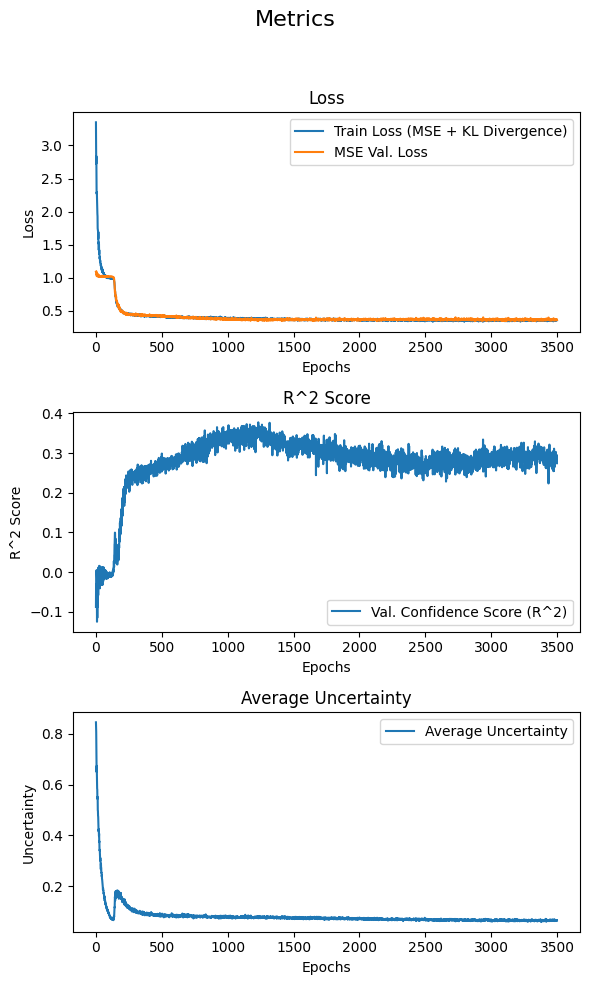

In [61]:
# Plot training history
fig, axes = plt.subplots(3, 1, figsize=(6, 10))
plt.suptitle('Metrics', fontsize=16)

# Losses
axes[0].plot(history['train_loss'], label='Train Loss (MSE + KL Divergence)')
axes[0].plot(history['val_loss'], label='MSE Val. Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Confidence Score
axes[1].plot(history['r2'], label='Val. Confidence Score (R^2)')
axes[1].set_title('R^2 Score')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('R^2 Score')
axes[1].legend()

# Uncertainty
axes[2].plot(history['avg_uncertainty'], label='Average Uncertainty')
axes[2].set_title('Average Uncertainty')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Uncertainty')
axes[2].legend()


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [62]:
# Get the metrics
model.eval()
y_true = y_test.numpy()
y_pred = []
uncertainties = []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        outputs_list = [model(X_batch, mc_dropout=True) for _ in range(1000)] # Increase the number of MC samples for better uncertainty estimation
        outputs_stack = torch.stack(outputs_list)  # Shape: (mc_samples, batch_size, num_classes)
        outputs_mean = outputs_stack.mean(dim=0)  # Average prediction
        outputs_std = outputs_stack.std(dim=0)
        y_pred.extend(outputs_mean.cpu().numpy())
        uncertainties.extend(outputs_std.mean(dim=1).cpu().numpy())

y_pred = np.array(y_pred).reshape(-1, 1)

# Unscale the predictions and true values
y_pred = target_scaler.inverse_transform(y_pred)
y_true = target_scaler.inverse_transform(y_true)

#### The basic regression metrics

In [ ]:
# MAE
mae = mean_absolute_error(y_true, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# RMSE
rmse = root_mean_squared_error(y_true, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# R^2 Score
r2 = r2_score(y_true, y_pred)
print(f"R^2 Score: {r2:.4f}")

# Average Uncertainty
avg_uncertainty = np.mean(uncertainties)
print(f"Average Uncertainty: {avg_uncertainty:.4f}")

# Explained Variance Score
evs = explained_variance_score(y_true, y_pred)
print(f"Explained Variance Score: {evs:.4f}")

# The results are almost identical to the previous training. So.the model didn't improve accuracy.
#  But Average Uncertainty this time is 0.0683 vs 0.0936, it means that the model now more confident in its prediction.

Mean Absolute Error (MAE): 39548.6484
Root Mean Squared Error (RMSE): 56289.1953
R^2 Score: 0.6817
Average Uncertainty: 0.0683
Explained Variance Score: 0.6847


#### Training results before hyperparameters optimization: 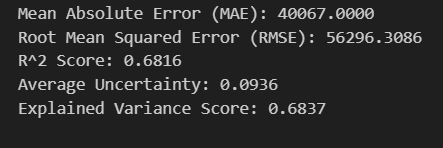

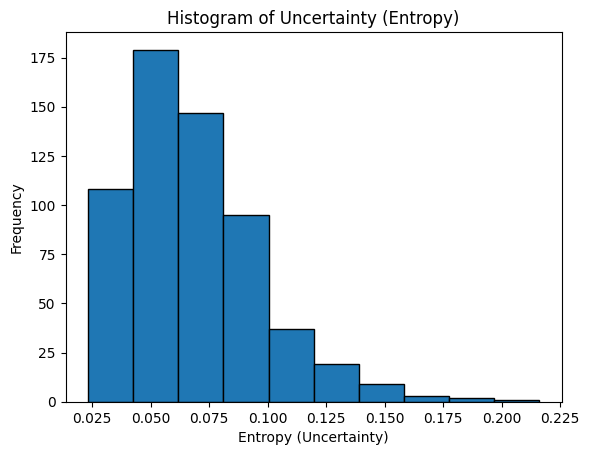

In [ ]:
# plot uncertainty histogram
plt.hist(uncertainties, bins=10, edgecolor='k')
plt.xlabel('Entropy (Uncertainty)')
plt.ylabel('Frequency')
plt.title('Histogram of Uncertainty (Entropy)')
plt.show()

# No big changes with entropy distribution

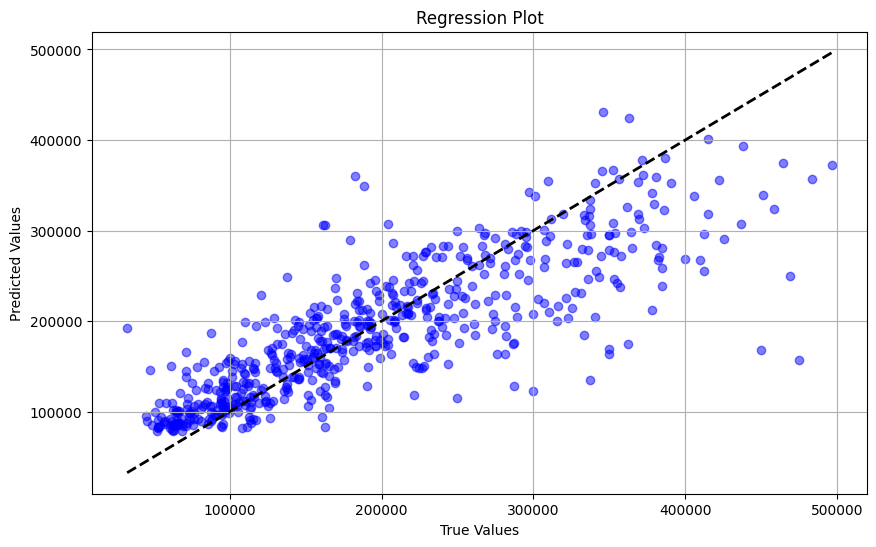

In [65]:
# Regression plot
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.5, color='blue')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
plt.title('Regression Plot')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.grid()
plt.show()

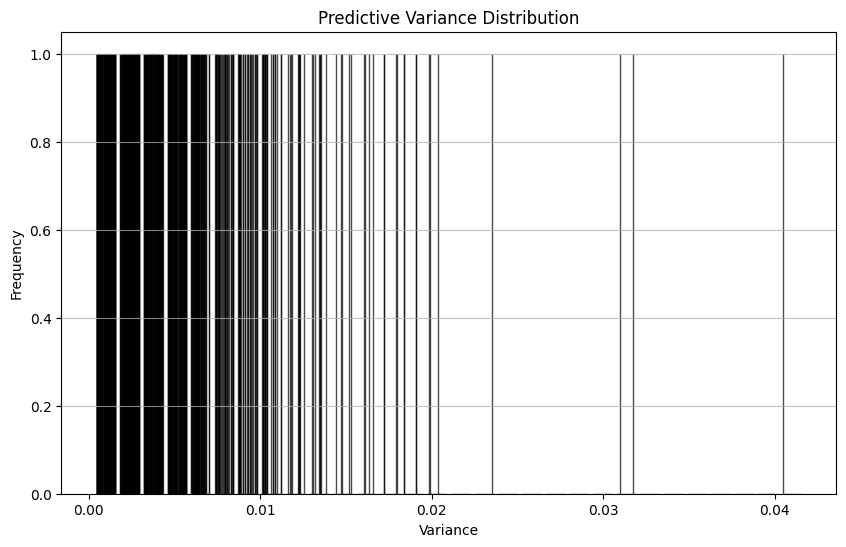

In [ ]:
# original code from ChatGPT and modified for this project (data and neural network structure)
# Assuming `model` performs MC Dropout and `test_loader` provides data
variances = []  # List to store predictive variance (or standard deviation)

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # Perform multiple forward passes for MC Dropout
        outputs_list = [model(X_batch, mc_dropout=True) for _ in range(10)]
        outputs_stack = torch.stack(outputs_list)
        
        # Calculate variance across the predictions
        variance = outputs_stack.var(dim=0).cpu().numpy()  # Variance of each prediction
        variances.extend(variance)

# Plot predictive variance (uncertainty)
plt.figure(figsize=(10, 6))
plt.hist(variances, bins=30, alpha=0.7, edgecolor='black')
plt.title('Predictive Variance Distribution')
plt.xlabel('Variance')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Here, also the same  - on the plot below we can see that most of the lines are packed around 0.00 – 0.02, which is a good sign,BUT
# we can see also a long right tail, which is telling that there are some predictions with higher uncertainty
# as a solution we can improve dataset or model structure / hyperparameters

In [67]:
jhvjh

NameError: name 'jhvjh' is not defined

### Use the model in practice (inference)

In [68]:
df.iloc[542]

housing_median_age                9.0000
total_rooms                    2404.0000
population                     1074.0000
median_income                     5.0198
median_house_value           151900.0000
distance_to_nearest_city         92.0300
ocean_proximity_<1H OCEAN         0.0000
ocean_proximity_INLAND            1.0000
ocean_proximity_ISLAND            0.0000
ocean_proximity_NEAR BAY          0.0000
Name: 542, dtype: float64

In [70]:
# ORIGINAL CODE FROM CHATGPT AND MODIFIER FOR THE TESTER ROW STRUCTURE FROM EARLIER COURSES

# Define the function for prediction with uncertainty
def predict_with_uncertainty(model, data, feature_scaler, target_scaler, mc_samples=100):
    """
    Predict the price and uncertainty (using MC Dropout) for a new row of data.

    :param model: The trained Bayesian Neural Network model
    :param data: Processed input data for prediction
    :param feature_scaler: Scaler for the input features (used during training)
    :param target_scaler: Scaler for the target variable (price) used during training
    :param mc_samples: Number of Monte Carlo samples to estimate uncertainty
    :return: predicted_price, uncertainty (standard deviation)
    """
    model.eval()  # Set the model to evaluation mode
    predictions = []

    with torch.no_grad():
        for _ in range(mc_samples):
            # Apply MC dropout during inference
            prediction = model(data, mc_dropout=True)  # Get predictions using MC dropout
            predictions.append(prediction.cpu().numpy())

    predictions = np.array(predictions).flatten()  # Flatten predictions to 1D array

    # Compute the mean (predicted value) and the uncertainty (standard deviation)
    predicted_price = predictions.mean()
    uncertainty = predictions.std()

    # Inverse transform the predicted price and uncertainty to original scale
    predicted_price = target_scaler.inverse_transform([[predicted_price]])[0][0]  # Rescale predicted price

    # Uncertainty might need to be scaled back to original scale (if it was scaled during training)
    # uncertainty = uncertainty * target_scaler.scale_[0]  # Scale the uncertainty back to original price scale

    return predicted_price, uncertainty


# Example new row for prediction (using your dataset)
tester_row = {
    "housing_median_age": 9.0000,
    "total_rooms": 2404.0000,
    "population": 1074.0000,
    "median_income": 5.0198,
    
    "distance_to_nearest_city": 92.0300,
    "ocean_proximity_<1H OCEAN": 0.0000,
    "ocean_proximity_INLAND": 1.0000,
    "ocean_proximity_ISLAND": 0.0000,
    "ocean_proximity_NEAR BAY": 0.0000
}

# Convert the new data to pandas DataFrame
tester_row = pd.DataFrame([tester_row])

# Normalize the input features using feature_scaler (if you scaled them during training)
processed_data = feature_scaler.transform(tester_row.values)

# Convert the scaled data into a tensor
processed_data_tensor = torch.tensor(processed_data, dtype=torch.float32)

# Call the prediction function to get the price and uncertainty
predicted_price, uncertainty = predict_with_uncertainty(model, processed_data_tensor, feature_scaler, target_scaler)

# Output the result
print("\nEstimated price for this house:")
print(f"$ {round(predicted_price, 2)}")
print(f"Uncertainty (Standard Deviation): {round(uncertainty, 2)}")
print("----------------")



Estimated price for this house:
$ 172532.58
Uncertainty (Standard Deviation): 0.05000000074505806
----------------


#### The model estimation is - median_house_value 172532.58 instead of 151900. So, hyperparemeters optimization didn't help. Almost the same result as we had before optimization.

